# ANIL sweep

In [1]:
import re, sys, pathlib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, not reimplemented: the smoothing window and the 1-SE construction must
# be the SAME here as in the sweep, or section 3 marks epochs the sweep never chose.
from ProVoice.training_scripts.sweep_population_hparams import smooth, SMOOTH_WINDOW

%matplotlib inline
pd.set_option("display.width", 220)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = _SRC.parent
RUNS = ROOT / "results/anil_sweep/runs"
MIN_SELECT_EPOCH = 3      # must match the sweep's --min-select-epoch

_PAT = re.compile(r"metrics_olr(.+?)_c(.+?)_j(.+?)_f(.+?)_s(\d+)$")


def load_curves(runs_dir: pathlib.Path) -> pd.DataFrame:
    """One long dataframe: a row per (run, epoch).

    Run identity comes from the FILENAME, which is the only place it is recorded --
    the metrics CSV itself carries no outer_lr/fold/seed columns.
    """
    out = []
    for f in sorted(runs_dir.glob("metrics_*.csv")):
        m = _PAT.match(f.stem)
        if not m:
            print(f"[skip] unparseable name: {f.name}")
            continue
        d = pd.read_csv(f)
        d = d[d["val_set_mae"].notna()].reset_index(drop=True)
        if d.empty:
            print(f"[skip] no meta-validation rows: {f.name}")
            continue
        d["outer_lr"] = float(m.group(1))
        d["crop"] = float(m.group(2))
        d["jitter"] = float(m.group(3))
        d["fold"] = m.group(4)
        d["seed"] = int(m.group(5))
        d["run"] = f.stem
        out.append(d)
    if not out:
        raise SystemExit(f"no curves found under {runs_dir}")
    return pd.concat(out, ignore_index=True)


C = load_curves(RUNS)
LRS = sorted(C.outer_lr.unique())
FOLDS = sorted(C.fold.unique())
SEEDS = sorted(C.seed.unique())
AUGS = sorted(set(zip(C.crop, C.jitter)))
CMAP = {lr: c for lr, c in zip(LRS, plt.get_cmap("viridis")(np.linspace(0, .85, len(LRS))))}

print(f"{C.run.nunique()} runs | outer_lr {LRS} | folds {FOLDS} | seeds {SEEDS} | (crop,jit) {AUGS}")
print(f"epochs per run: min {C.groupby('run').size().min()}, "
      f"median {int(C.groupby('run').size().median())}, max {C.groupby('run').size().max()}")
has_perk = [c for c in C.columns if c.startswith("val_set_mae_k")]
print(f"per-K columns: {has_perk if has_perk else 'none (run predates --val-ks)'}")

96 runs | outer_lr [0.0001, 0.0003, 0.001, 0.003] | folds ['001-005', '002-006', '003-007', '004-008', '009-011', '010-012'] | seeds [0, 1] | (crop,jit) [(0.0, 0.0), (0.2, 0.02)]
epochs per run: min 11, median 15, max 53
per-K columns: ['val_set_mae_k5', 'val_set_mae_k10', 'val_set_mae_k15', 'val_set_mae_k20', 'val_set_mae_k25', 'val_set_mae_k30', 'val_set_mae_k40', 'val_set_mae_k45', 'val_set_mae_k50', 'val_set_mae_k55', 'val_set_mae_k60']


---
## 1. All curves, one panel per fold

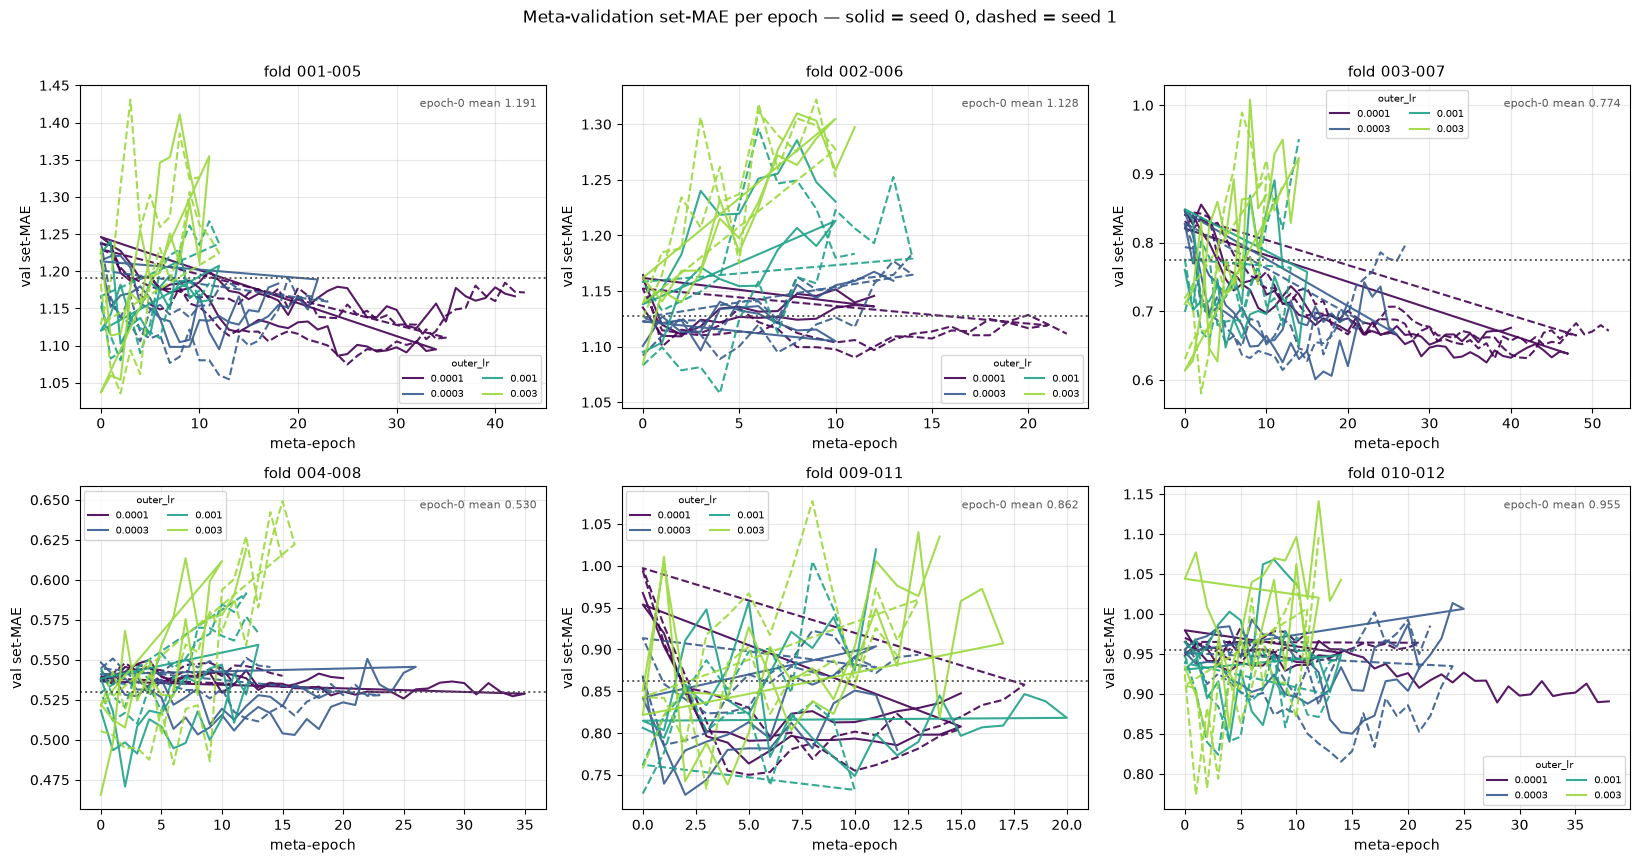

**Fold levels** — this spread is why the panels are not on one scale

fold,001-005,002-006,003-007,004-008,009-011,010-012
mean val set-MAE,1.162,1.159,0.715,0.538,0.847,0.938


between-fold sd 0.247  vs  outer_lr spread 0.069


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.5))
for ax, fold in zip(axes.ravel(), FOLDS):
    sub = C[C.fold == fold]
    for (lr, seed), g in sub.groupby(["outer_lr", "seed"]):
        ax.plot(g.epoch, g.val_set_mae, color=CMAP[lr], lw=1.5,
                ls="-" if seed == SEEDS[0] else "--", alpha=.9,
                label=f"{lr:g}" if seed == SEEDS[0] else None)
    ep0 = sub[sub.epoch == 0].val_set_mae.mean()
    ax.axhline(ep0, ls=":", c="0.35", lw=1.4)
    ax.text(.98, .96, f"epoch-0 mean {ep0:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="0.35")
    ax.set_title(f"fold {fold}", fontsize=11)
    ax.set_xlabel("meta-epoch"); ax.set_ylabel("val set-MAE")
    ax.grid(alpha=.3)
    ax.legend(fontsize=7, title="outer_lr", title_fontsize=7, ncol=2)
for ax in axes.ravel()[len(FOLDS):]:
    ax.axis("off")
fig.suptitle("Meta-validation set-MAE per epoch — solid = seed 0, dashed = seed 1", y=1.01)
plt.tight_layout(); plt.show()

lv = C.groupby("fold").val_set_mae.mean()
display(Markdown("**Fold levels** — this spread is why the panels are not on one scale"))
display(lv.round(3).to_frame("mean val set-MAE").T)
print(f"between-fold sd {lv.std(ddof=1):.3f}  vs  outer_lr spread "
      f"{C.groupby('outer_lr').val_set_mae.mean().pipe(lambda s: s.max() - s.min()):.3f}")

---
## 2. Centred within fold

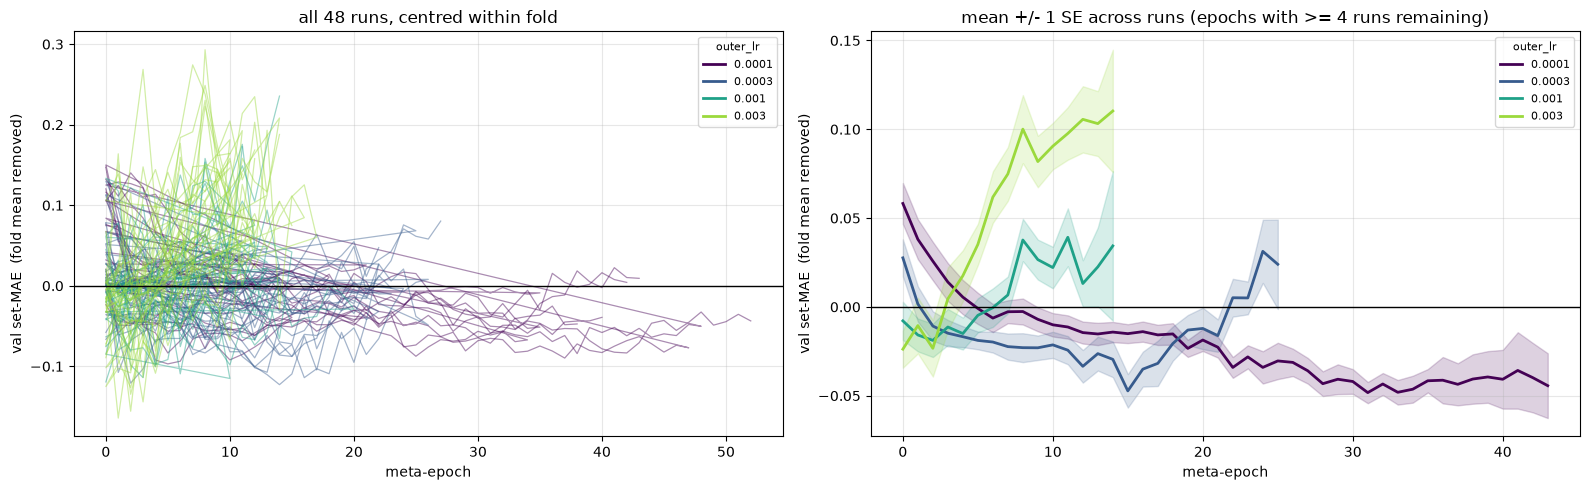

In [3]:
C = C.copy()
C["centred"] = C.val_set_mae - C.groupby("fold").val_set_mae.transform("mean")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: every run, faint, coloured by lr
for (lr, fold, seed), g in C.groupby(["outer_lr", "fold", "seed"]):
    axes[0].plot(g.epoch, g.centred, color=CMAP[lr], lw=.9, alpha=.45)
for lr in LRS:
    axes[0].plot([], [], color=CMAP[lr], lw=2, label=f"{lr:g}")
axes[0].axhline(0, c="k", lw=1)
axes[0].set_title("all 48 runs, centred within fold")
axes[0].set_xlabel("meta-epoch"); axes[0].set_ylabel("val set-MAE  (fold mean removed)")
axes[0].grid(alpha=.3); axes[0].legend(fontsize=8, title="outer_lr", title_fontsize=8)

# right: mean +/- se across runs, per lr
for lr in LRS:
    g = C[C.outer_lr == lr].groupby("epoch").centred.agg(["mean", "std", "count"])
    g = g[g["count"] >= 4]        # drop the ragged tail where few runs survive
    se = g["std"] / np.sqrt(g["count"])
    axes[1].plot(g.index, g["mean"], color=CMAP[lr], lw=2, label=f"{lr:g}")
    axes[1].fill_between(g.index, g["mean"] - se, g["mean"] + se, color=CMAP[lr], alpha=.18)
axes[1].axhline(0, c="k", lw=1)
axes[1].set_title("mean +/- 1 SE across runs (epochs with >= 4 runs remaining)")
axes[1].set_xlabel("meta-epoch"); axes[1].set_ylabel("val set-MAE  (fold mean removed)")
axes[1].grid(alpha=.3); axes[1].legend(fontsize=8, title="outer_lr", title_fontsize=8)
plt.tight_layout(); plt.show()

---
## 3. Query loss 

`query_loss` is the outer objective's own value: soft-CORN NLL on the episode's query
segments under the inner-adapted head, averaged over the epoch's episodes.

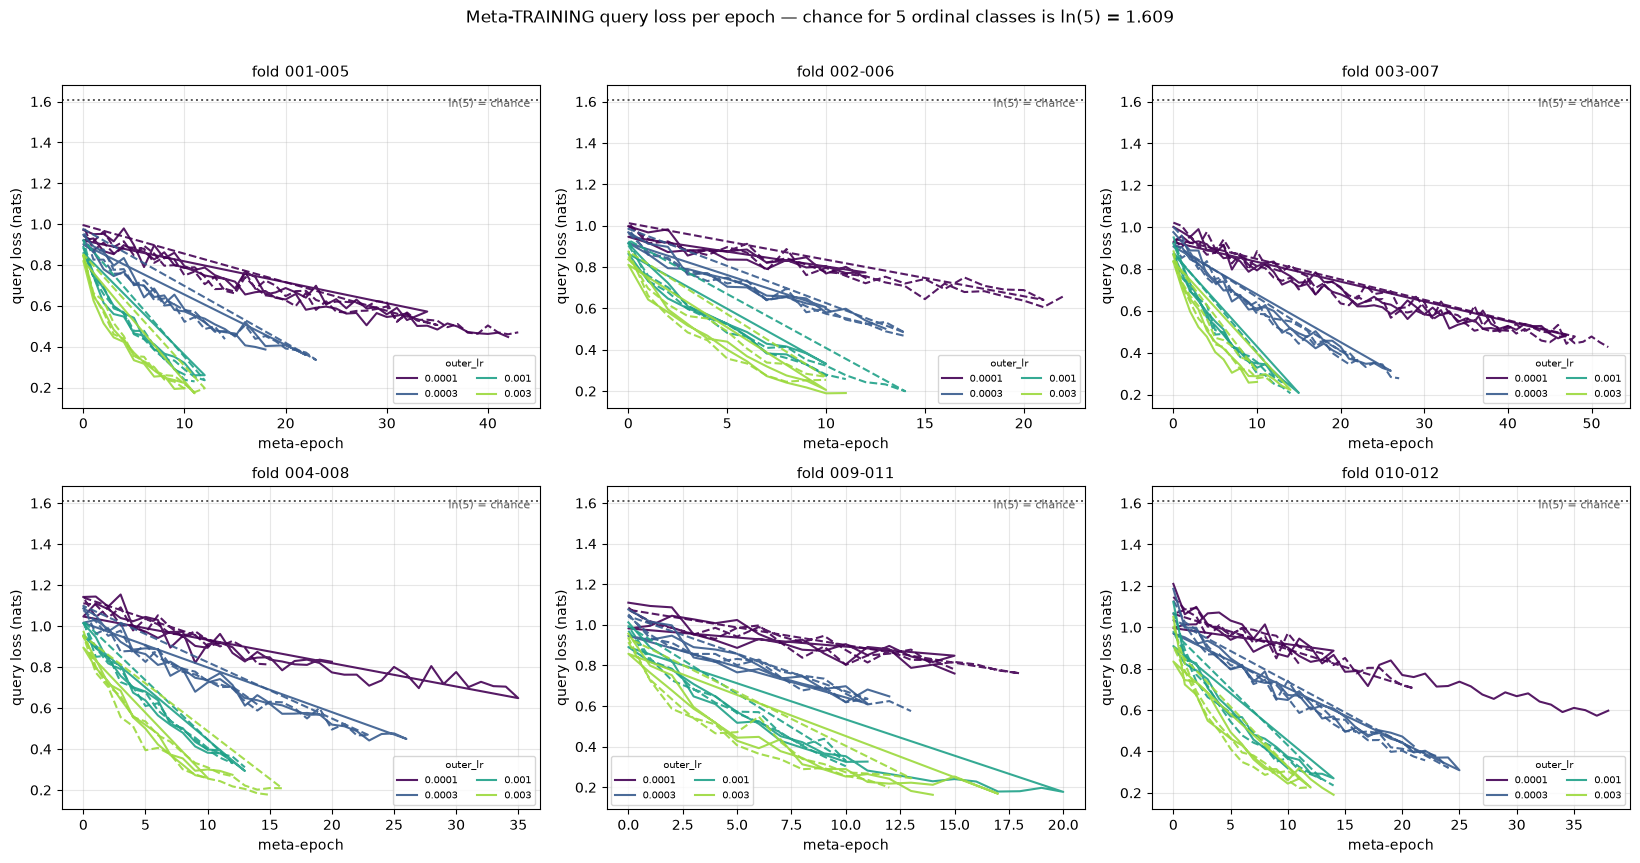

**Did the meta-objective move?** Positive `drop` = yes.

,first,last,drop
outer_lr,,,
0.0001,1.033,0.670,0.363
0.0003,1.004,0.454,0.550
0.0010,0.948,0.271,0.677
0.0030,0.892,0.222,0.670


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.5))
for ax, fold in zip(axes.ravel(), FOLDS):
    for (lr, seed), g in C[C.fold == fold].groupby(["outer_lr", "seed"]):
        ax.plot(g.epoch, g.query_loss, color=CMAP[lr], lw=1.5,
                ls="-" if seed == SEEDS[0] else "--", alpha=.9,
                label=f"{lr:g}" if seed == SEEDS[0] else None)
    ax.axhline(np.log(5), ls=":", c="0.35", lw=1.4)
    ax.text(.98, .96, "ln(5) = chance", transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="0.35")
    ax.set_title(f"fold {fold}", fontsize=11)
    ax.set_xlabel("meta-epoch"); ax.set_ylabel("query loss (nats)")
    ax.grid(alpha=.3); ax.legend(fontsize=7, title="outer_lr", title_fontsize=7, ncol=2)
for ax in axes.ravel()[len(FOLDS):]:
    ax.axis("off")
fig.suptitle("Meta-TRAINING query loss per epoch — chance for 5 ordinal classes is ln(5) = 1.609",
             y=1.01)
plt.tight_layout(); plt.show()

q = C.groupby(["outer_lr", "run"]).query_loss.agg(["first", "last"]).reset_index()
q["drop"] = q["first"] - q["last"]
display(Markdown("**Did the meta-objective move?** Positive `drop` = yes."))
display(q.groupby("outer_lr")[["first", "last", "drop"]].mean().round(3))

---
## 4. Run health

Two things that invalidate a run rather than merely making it worse:

* **Curve length.** Runs stop at `--meta-epochs` or on `--patience`. A configuration
  whose runs all early-stop very short has an `M*` estimated from very little curve.
* **iMAML inner residual.** The implicit meta-gradient is exact only at the inner
  problem's argmin. `inner_res_max` above `--imaml-tol` (1e-4) means the solve did not
  get there, so the meta-gradients for those episodes are biased.

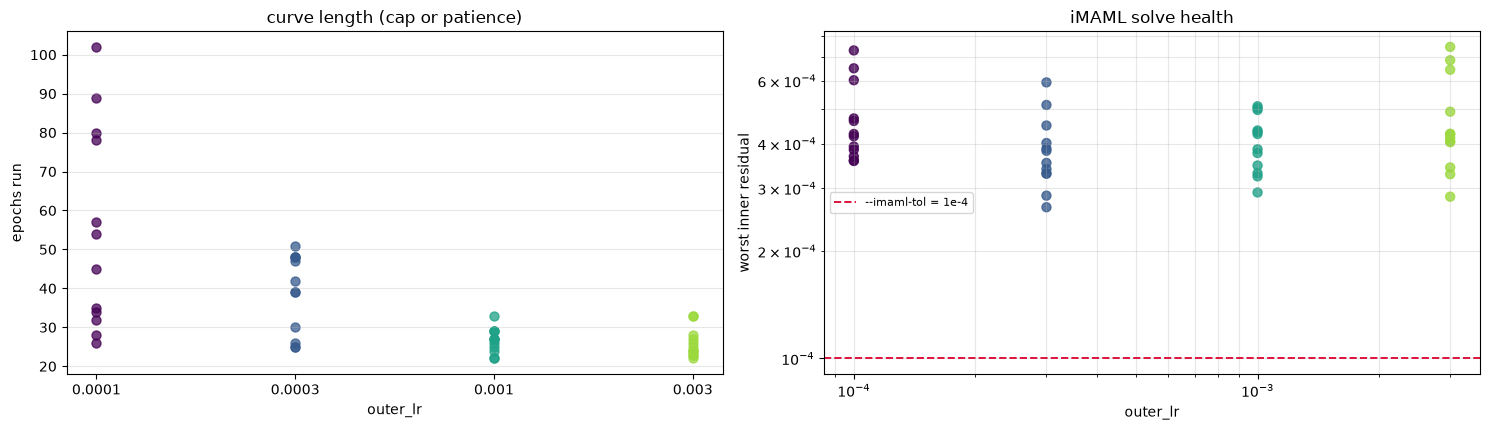

,n,epochs_mean,epochs_min,res_max,unconv_frac
outer_lr,,,,,
0.0001,12,55.000000,26,0.000730,0.149313
0.0003,12,39.000000,25,0.000594,0.124972
0.0010,12,26.666667,22,0.000509,0.109585
0.0030,12,26.000000,22,0.000747,0.096292



48/48 run(s) with a residual above tol -> [(0.0001, '001-005'), (0.0001, '002-006'), (0.0001, '003-007'), (0.0001, '004-008'), (0.0001, '009-011'), (0.0001, '010-012'), (0.0003, '001-005'), (0.0003, '002-006'), (0.0003, '003-007'), (0.0003, '004-008'), (0.0003, '009-011'), (0.0003, '010-012'), (0.001, '001-005'), (0.001, '002-006'), (0.001, '003-007'), (0.001, '004-008'), (0.001, '009-011'), (0.001, '010-012'), (0.003, '001-005'), (0.003, '002-006'), (0.003, '003-007'), (0.003, '004-008'), (0.003, '009-011'), (0.003, '010-012')]


In [5]:
H = C.groupby(["outer_lr", "fold", "seed"]).agg(
    n_epochs=("epoch", "size"),
    res_max=("inner_res_max", "max"),
    unconv=("inner_unconverged", "sum"),
    episodes=("n_episodes", "sum")).reset_index()
H["unconv_frac"] = H.unconv / H.episodes.replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
for i, lr in enumerate(LRS):
    axes[0].scatter([i] * (H.outer_lr == lr).sum(), H[H.outer_lr == lr].n_epochs,
                    color=CMAP[lr], s=42, alpha=.75)
axes[0].set_xticks(range(len(LRS))); axes[0].set_xticklabels([f"{l:g}" for l in LRS])
axes[0].set_xlabel("outer_lr"); axes[0].set_ylabel("epochs run")
axes[0].set_title("curve length (cap or patience)"); axes[0].grid(alpha=.3, axis="y")

axes[1].scatter(H.outer_lr, H.res_max, c=[CMAP[l] for l in H.outer_lr], s=42, alpha=.8)
axes[1].axhline(1e-4, ls="--", c="crimson", lw=1.4, label="--imaml-tol = 1e-4")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("outer_lr"); axes[1].set_ylabel("worst inner residual")
axes[1].set_title("iMAML solve health"); axes[1].grid(alpha=.3, which="both"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

display(H.groupby("outer_lr").agg(
    n=("n_epochs", "size"), epochs_mean=("n_epochs", "mean"), epochs_min=("n_epochs", "min"),
    res_max=("res_max", "max"), unconv_frac=("unconv_frac", "mean")).round(6))
bad = H[H.res_max > 1e-4]
print(f"\n{len(bad)}/{len(H)} run(s) with a residual above tol"
      + (f" -> {sorted(set(zip(bad.outer_lr, bad.fold)))}" if len(bad) else " — solves are healthy"))

---
## 5. Per-K breakdown

The reported `val_set_mae` is a **flat mean** over drivers x that K grid.

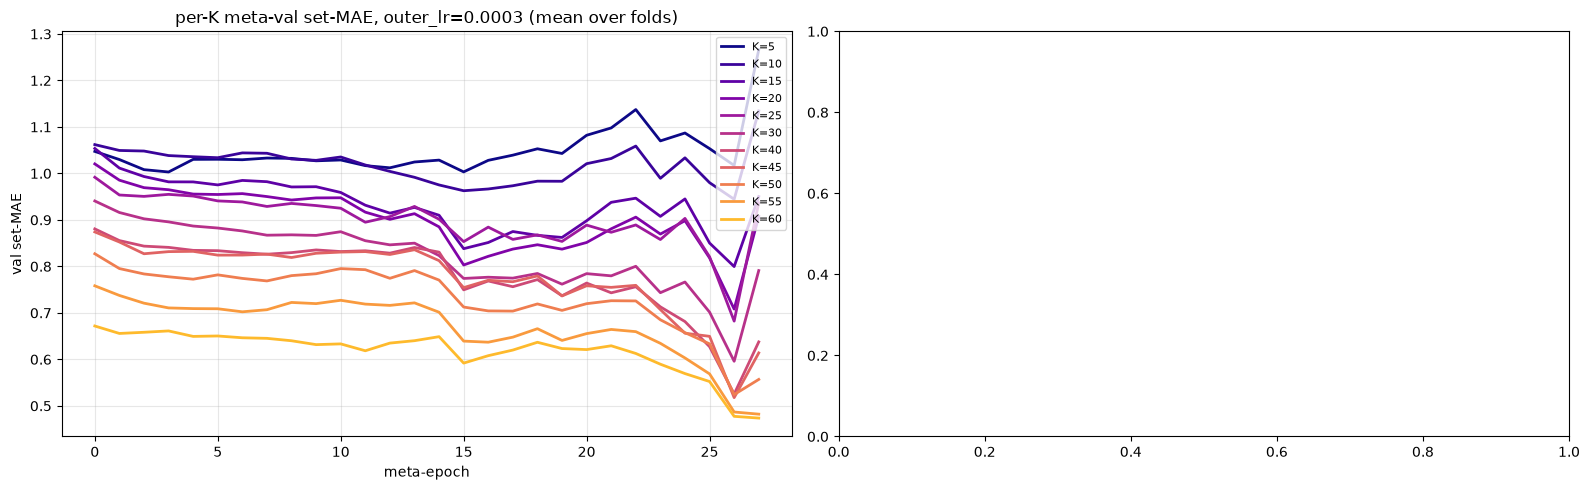

In [6]:
kcols = sorted([c for c in C.columns if c.startswith("val_set_mae_k")],
               key=lambda c: int(c.rsplit("k", 1)[1]))
if not kcols:
    print("No per-K columns in these curves — run predates --val-ks. Nothing to plot.")
else:
    ks = [int(c.rsplit("k", 1)[1]) for c in kcols]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # left: per-K curves at the SELECTED config, centred within fold
    best_lr = C.outer_lr.iloc[0] if len(LRS) == 1 else sorted(
        LRS, key=lambda l: C[C.outer_lr == l].val_set_mae.mean())[0]
    sub = C[C.outer_lr == best_lr]
    kc = plt.get_cmap("plasma")(np.linspace(0, .85, len(ks)))
    for col, k, c in zip(kcols, ks, kc):
        g = sub.groupby("epoch")[col].mean()
        axes[0].plot(g.index, g.values, color=c, lw=2, label=f"K={k}")
    axes[0].set_title(f"per-K meta-val set-MAE, outer_lr={best_lr:g} (mean over folds)")
    axes[0].set_xlabel("meta-epoch"); axes[0].set_ylabel("val set-MAE")
    axes[0].grid(alpha=.3); axes[0].legend(fontsize=8)

    plt.tight_layout(); plt.show()
